#**TAREA 1 EQUIPO 2**

##**Integrantes:**


*   Ascencio Diaz Enrique
*   Avilés Jiménez Erick Yael
*   Flores Escandon Hiram
*   Garcia Garcia Carlos Eduardo
*   Gómez Méndez Alberto
*   Mayo Maldonado Emiliano
*   Reboyo Cruz David



#**1-Carga del dataset**

In [58]:
# Se importan las librerías necesarias para el análisis de datos.
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [59]:
# En esta parte se carga el conjunto de datos desde un archivo (por ejemplo CSV o Excel).
# El archivo se convierte en un DataFrame de pandas para poder manipularlo
df=pd.read_csv("https://raw.githubusercontent.com/319165515-a11y/ANALISIS_REGRESI-N-/refs/heads/main/insurance_claims.csv")

In [60]:
# Se muestran las primeras filas del dataset para conocer la estructura
# de la base de datos, los nombres de las columnas y el tipo de información
df.head(5)
df_1=df.copy()

In [61]:
# Aquí se obtiene información general del Dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 40 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   months_as_customer           1000 non-null   int64  
 1   age                          1000 non-null   int64  
 2   policy_number                1000 non-null   int64  
 3   policy_bind_date             1000 non-null   object 
 4   policy_state                 1000 non-null   object 
 5   policy_csl                   1000 non-null   object 
 6   policy_deductable            1000 non-null   int64  
 7   policy_annual_premium        1000 non-null   float64
 8   umbrella_limit               1000 non-null   int64  
 9   insured_zip                  1000 non-null   int64  
 10  insured_sex                  1000 non-null   object 
 11  insured_education_level      1000 non-null   object 
 12  insured_occupation           1000 non-null   object 
 13  insured_hobbies    

In [5]:
# Se revisan los valores únicos de una variable para entender
# las categorías o tipos de datos que contiene la columna.
df['auto_make'].unique()

array(['Saab', 'Mercedes', 'Dodge', 'Chevrolet', 'Accura', 'Nissan',
       'Audi', 'Toyota', 'Ford', 'Suburu', 'BMW', 'Jeep', 'Honda',
       'Volkswagen'], dtype=object)

#**2-Análisis Exploratorio**

En esta parte hacemos un analisis exploratorio para poder ver como se ve la infomacion y asi poder analizar de mejor manera el dataset


In [6]:
# Se agrupan los datos utilizando groupby para analizar
# cómo se comporta una variable con respecto a otra.
df_analisis_1=df[['policy_state','policy_number']].groupby('policy_state').count()
df_analisis_1

,policy_number
policy_state,
IL,338
IN,310
OH,352


Text(0.5, 1.0, 'Count of sinesters by state ')

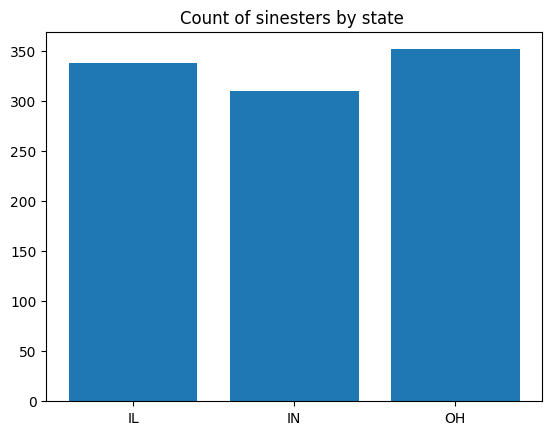

In [7]:
#hacemos una grafica de barras para verlo de mejor manera
plt.bar(x=df_analisis_1.index, height=df_analisis_1['policy_number'])
plt.title("Count of sinesters by state ")

In [8]:
# Aquí se genera una tabla resumen que muestra estadísticas
# o métricas calculadas a partir de los datos agrupados.
tabla3 = pd.pivot_table(df,
                        values='total_claim_amount',
                        index='incident_state',
                        columns='insured_sex',
                        aggfunc='sum',
                        fill_value=0)
print(tabla3)

insured_sex      FEMALE     MALE
incident_state                  
NC              2909110  2512120
NY              7825200  6948570
OH               320440   824280
PA               768700   718450
SC              7906970  5631180
VA              3538700  1961070
WV              5376240  5520910


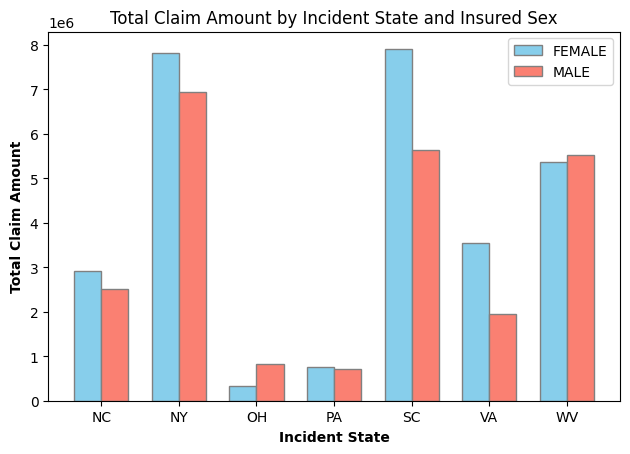

In [9]:
# Se crea una gráfica de barras para visualizar la comparación
# entre diferentes generos
bar_width = 0.35
r1 = np.arange(len(tabla3.index))
r2 = [x + bar_width for x in r1]

plt.bar(r1, tabla3['FEMALE'], color='skyblue', width=bar_width, edgecolor='grey', label='FEMALE')
plt.bar(r2, tabla3['MALE'], color='salmon', width=bar_width, edgecolor='grey', label='MALE')

plt.xlabel('Incident State', fontweight='bold')
plt.xticks([r + bar_width/2 for r in range(len(tabla3.index))], tabla3.index)
plt.ylabel('Total Claim Amount', fontweight='bold')
plt.title('Total Claim Amount by Incident State and Insured Sex')
plt.legend()
plt.tight_layout()
plt.show()

In [10]:
#Creamos la tabla 2 que nos da informacion de tipo de marca de autos tienen mas total_claim_amount
tabla_2=df[['auto_make','total_claim_amount']].groupby('auto_make').sum().sort_values(by='total_claim_amount')
tabla_2

,total_claim_amount
auto_make,
Honda,2844320
Toyota,3256660
Mercedes,3404190
Jeep,3457790
Volkswagen,3458130
Accura,3571280
Audi,3752480
Chevrolet,4008740
Nissan,4020530


Text(0.5, 1.0, 'Total claim amount by auto make')

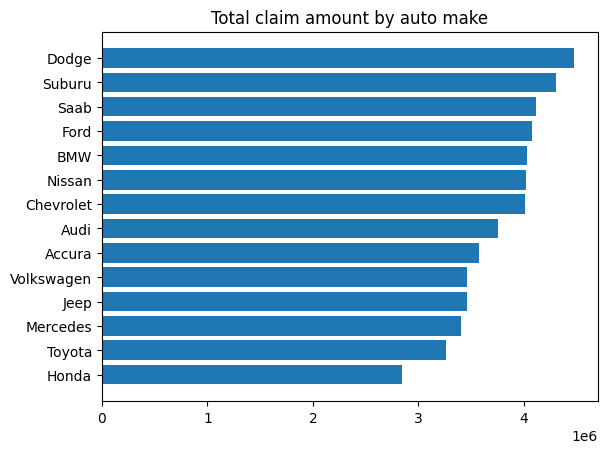

In [11]:
#Lo representamos de forma de grafica de barras para una mejor visualizacion
plt.barh(y=tabla_2.index, width=tabla_2['total_claim_amount'])
plt.title("Total claim amount by auto make")

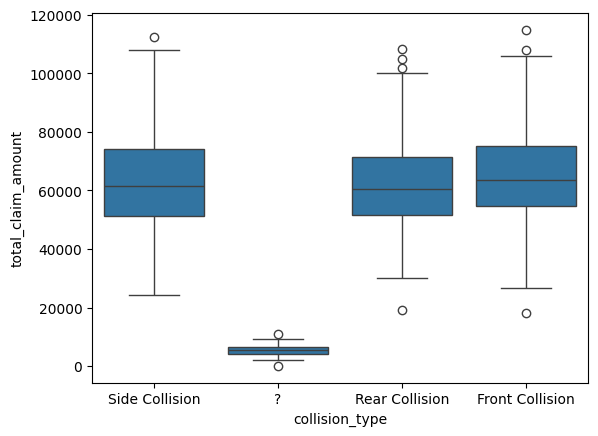

In [12]:
sns.boxplot(x='collision_type', y='total_claim_amount', data=df)
plt.show()

<Axes: xlabel='number_of_vehicles_involved', ylabel='total_claim_amount'>

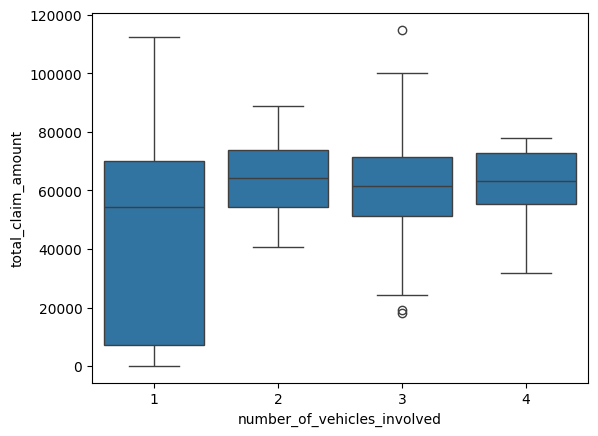

In [13]:
#numero de vehiculos involucrados
sns.boxplot(x='number_of_vehicles_involved', y='total_claim_amount', data=df)

In [14]:
#severidad por estado
df.groupby('incident_state')['total_claim_amount'].mean().sort_values()

,total_claim_amount
incident_state,
NC,49283.909091
PA,49571.666667
OH,49770.434783
VA,49997.909091
WV,50217.281106
SC,54589.314516
NY,56388.435115


In [15]:
#definicion de loss ratio
df['loss_ratio'] = df['total_claim_amount'] / df['policy_annual_premium']

In [16]:
df[['total_claim_amount','policy_annual_premium','loss_ratio']].head()

,total_claim_amount,policy_annual_premium,loss_ratio
0,71610,1406.91,50.898778
1,5070,1197.22,4.234811
2,34650,1413.14,24.519864
3,63400,1415.74,44.782234
4,6500,1583.91,4.103769


In [17]:
df['loss_ratio'].mean()

np.float64(43.771087544426024)

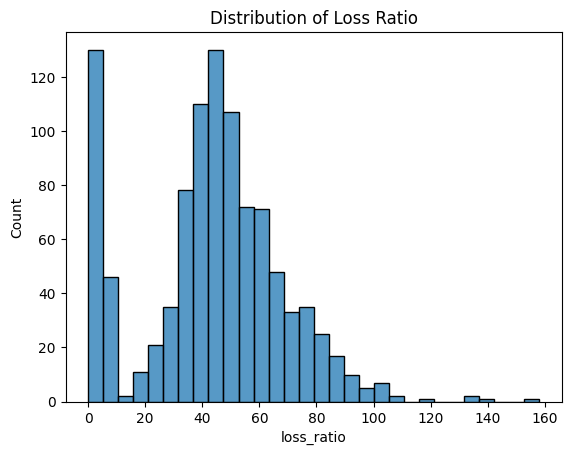

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['loss_ratio'], bins=30)
plt.title("Distribution of Loss Ratio")
plt.show()

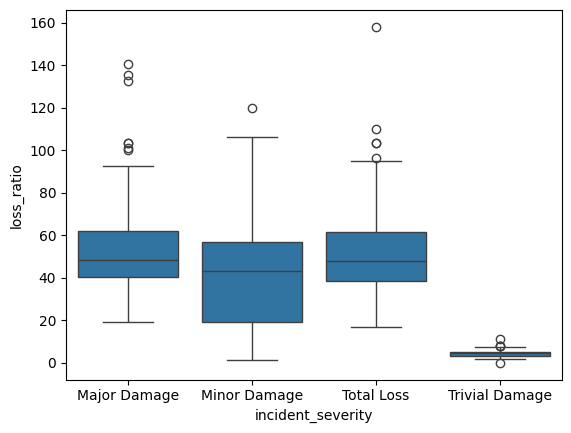

In [19]:
sns.boxplot(x='incident_severity', y='loss_ratio', data=df)
plt.show()

In [20]:
#severidad (costo promedio de los siniestros)
severity = df['total_claim_amount'].mean()
severity

np.float64(52761.94)

In [21]:
#severidad por tipo de accidente
df.groupby('incident_type')['total_claim_amount'].mean().sort_values(ascending=False)

,total_claim_amount
incident_type,
Single Vehicle Collision,64445.459057
Multi-vehicle Collision,61637.016706
Vehicle Theft,5517.234043
Parked Car,5308.214286


In [22]:
#severidad por estado
df.groupby('incident_state')['total_claim_amount'].mean()

,total_claim_amount
incident_state,
NC,49283.909091
NY,56388.435115
OH,49770.434783
PA,49571.666667
SC,54589.314516
VA,49997.909091
WV,50217.281106


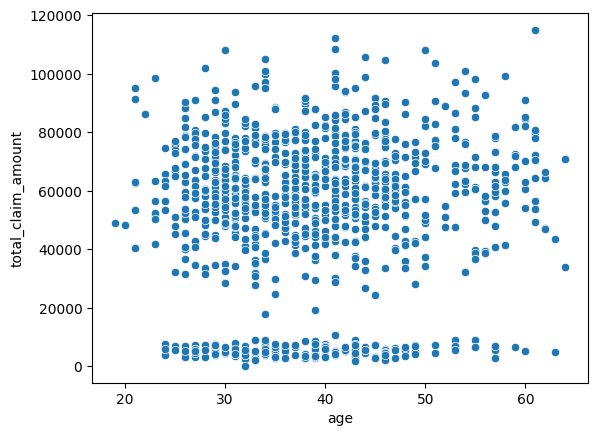

In [23]:
#Relacion que hay entre la edad y el total_claim el cual se nota que no tiene relacion alguna
sns.scatterplot(x='age', y='total_claim_amount', data=df)
plt.show()

##**Clasificación de variables númericas y categóricas**

Aquí se crean nuevas variables o se modifican las existentes para facilitar el análisis posterior o mejorar la interpretación de los datos.

In [24]:
var_num=['months_as_customer','age','policy_deductable','policy_annual_premium','umbrella_limit','capital-gains','capital-loss','number_of_vehicles_involved','bodily_injuries','witnesses','total_claim_amount','injury_claim','property_claim','vehicle_claim']

In [25]:
var_cat_nom=['policy_number','policy_state','insured_zip']

In [26]:
var_mod=['months_as_customer','age']

#3-**Preprocesamiento de variables**

In [27]:
# Primero se ve cuántas columnas tiene el dataframe y cuáles son,
# para entender cómo viene la base de datos originalmente.
print("Columnas originales:", df.shape[1])
print(df.columns.tolist())

# Variables a eliminar
cols_to_drop = [
    "_c39",                # columna vacía
    "policy_number",       # identificador
    "injury_claim",        # fuga de información
    "property_claim",      # fuga de información
    "vehicle_claim",       # fuga de información
    "incident_location",   # demasiada granularidad
    "insured_zip",         # demasiada granularidad
    "fraud_reported"       # no queremos usar fraude para predecir monto
]

# Eliminar solo las que existan en el dataframe
df = df.drop(columns=[col for col in cols_to_drop if col in df.columns])

# Si también quieres eliminar incident_city, descomenta esta línea:
# df = df.drop(columns=["incident_city"], errors="ignore")

# Revisar resultado
print("\nColumnas después de limpieza:", df.shape[1])
print(df.columns.tolist())

# Vista general
print("\nInformación del dataframe limpio:")
print(df.info())

Columnas originales: 41
['months_as_customer', 'age', 'policy_number', 'policy_bind_date', 'policy_state', 'policy_csl', 'policy_deductable', 'policy_annual_premium', 'umbrella_limit', 'insured_zip', 'insured_sex', 'insured_education_level', 'insured_occupation', 'insured_hobbies', 'insured_relationship', 'capital-gains', 'capital-loss', 'incident_date', 'incident_type', 'collision_type', 'incident_severity', 'authorities_contacted', 'incident_state', 'incident_city', 'incident_location', 'incident_hour_of_the_day', 'number_of_vehicles_involved', 'property_damage', 'bodily_injuries', 'witnesses', 'police_report_available', 'total_claim_amount', 'injury_claim', 'property_claim', 'vehicle_claim', 'auto_make', 'auto_model', 'auto_year', 'fraud_reported', '_c39', 'loss_ratio']

Columnas después de limpieza: 33
['months_as_customer', 'age', 'policy_bind_date', 'policy_state', 'policy_csl', 'policy_deductable', 'policy_annual_premium', 'umbrella_limit', 'insured_sex', 'insured_education_leve

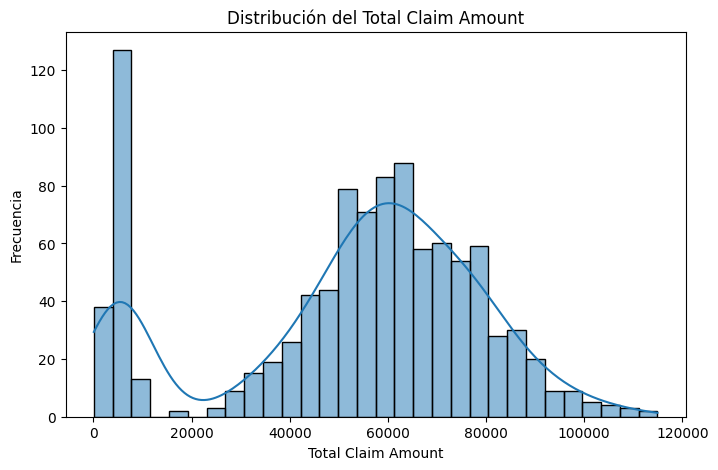

In [28]:
#vemos de que manera se distribuyr el total claim

plt.figure(figsize=(8,5))
sns.histplot(df["total_claim_amount"], bins=30, kde=True)
plt.title("Distribución del Total Claim Amount")
plt.xlabel("Total Claim Amount")
plt.ylabel("Frecuencia")
plt.show()

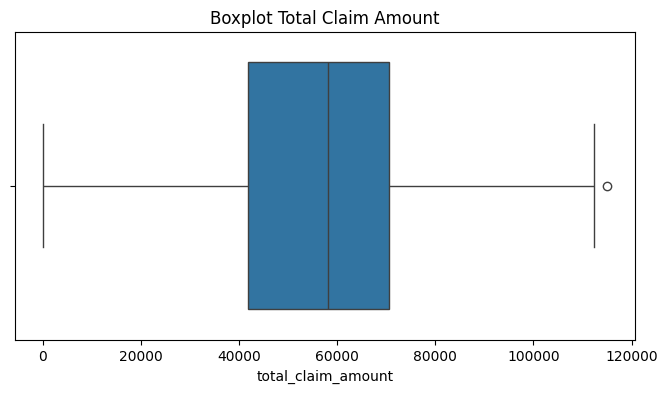

In [29]:
# Se crea un boxplot de la variable "total_claim_amount" para visualizar
# cómo se distribuyen los montos de los reclamos y detectar posibles valores atípicos.
plt.figure(figsize=(8,4))
sns.boxplot(x=df["total_claim_amount"])
plt.title("Boxplot Total Claim Amount")
plt.show()

In [30]:
# Se calculan estadísticas descriptivas de la variable "total_claim_amount",
# como el promedio, mínimo, máximo, cuartiles y desviación estándar,
# para entender mejor la distribución de los montos de los reclamos.
df["total_claim_amount"].describe()

,total_claim_amount
count,1000.00000
mean,52761.94000
std,26401.53319
min,100.00000
25%,41812.50000
50%,58055.00000
75%,70592.50000
max,114920.00000


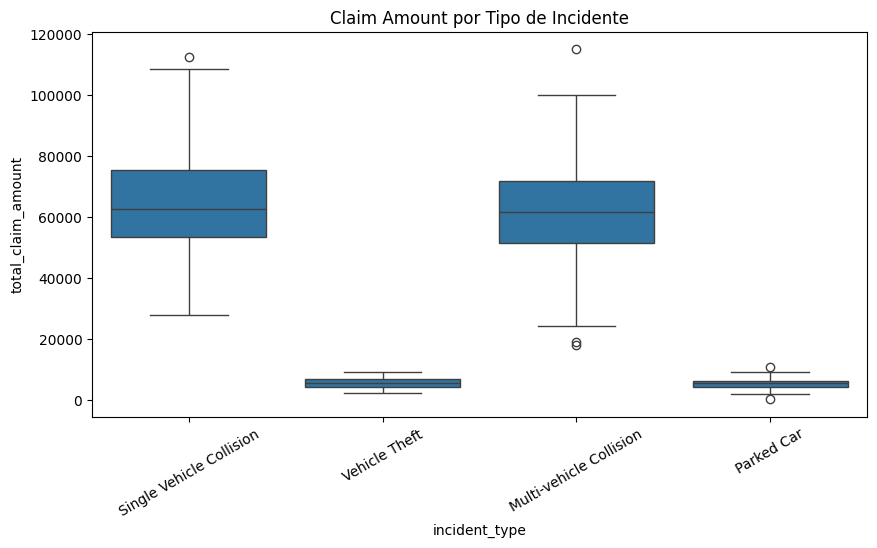

,count,mean,std,min,25%,50%,75%,max
incident_type,,,,,,,,
Multi-vehicle Collision,419.0,61637.016706,15585.757897,18000.0,51580.0,61650.0,71880.0,114920.0
Parked Car,84.0,5308.214286,1771.670752,100.0,4267.5,5490.0,6195.0,10790.0
Single Vehicle Collision,403.0,64445.459057,16337.324342,27700.0,53450.0,62640.0,75535.0,112320.0
Vehicle Theft,94.0,5517.234043,1681.634129,2250.0,4320.0,5495.0,6920.0,9100.0


In [31]:
# Se crea un boxplot para visualizar cómo se distribuyen los montos de reclamo
# (total_claim_amount) según el tipo de incidente (incident_type),
# lo que ayuda a comparar si algunos tipos de incidentes generan reclamos más altos.
plt.figure(figsize=(10,5))
sns.boxplot(x="incident_type", y="total_claim_amount", data=df)
plt.xticks(rotation=30)
plt.title("Claim Amount por Tipo de Incidente")
plt.show()

df.groupby("incident_type")["total_claim_amount"].describe()

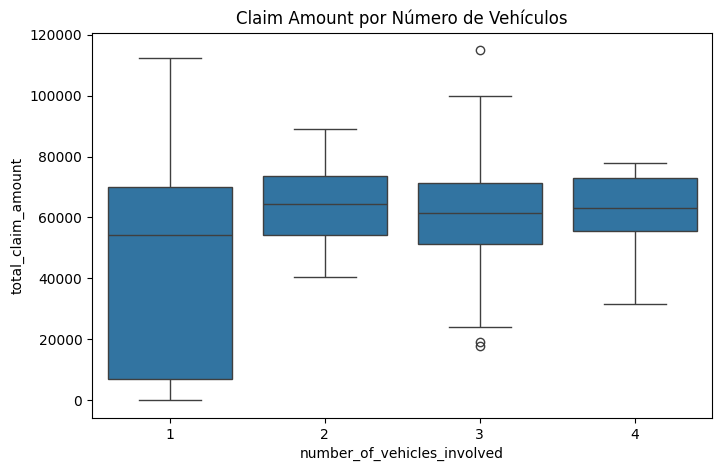

,count,mean,std,min,25%,50%,75%,max
number_of_vehicles_involved,,,,,,,,
1,581.0,46361.497418,30456.318918,100.0,7040.0,54340.0,70000.0,112320.0
2,30.0,64053.000000,12974.834568,40600.0,54285.0,64410.0,73750.0,88920.0
3,358.0,61442.988827,15964.321258,18000.0,51377.5,61465.0,71350.0,114920.0
4,31.0,61539.677419,13519.171938,31680.0,55550.0,63120.0,72820.0,77800.0


In [32]:
# Se crea un boxplot para ver cómo se distribuyen los montos de reclamo
# dependiendo del número de vehículos involucrados en el incidente.
plt.figure(figsize=(8,5))
sns.boxplot(x="number_of_vehicles_involved", y="total_claim_amount", data=df)
plt.title("Claim Amount por Número de Vehículos")
plt.show()

df.groupby("number_of_vehicles_involved")["total_claim_amount"].describe()

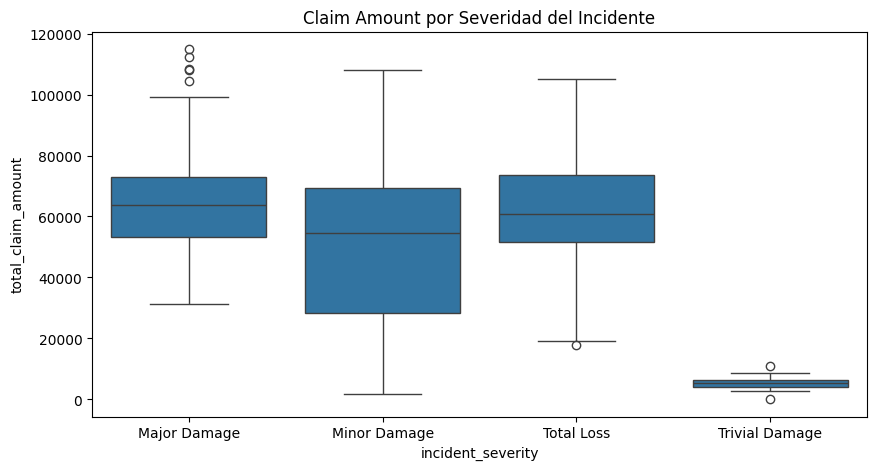

,count,mean,std,min,25%,50%,75%,max
incident_severity,,,,,,,,
Major Damage,276.0,64067.173913,15057.704014,31350.0,53415.0,63660.0,72810.0,114920.0
Minor Damage,354.0,48642.683616,28783.459227,1920.0,28185.0,54645.0,69460.0,108030.0
Total Loss,280.0,62081.214286,16171.794286,18000.0,51585.0,60945.0,73705.0,105040.0
Trivial Damage,90.0,5301.666667,1666.939772,100.0,4222.5,5350.0,6467.5,10790.0


In [33]:
# Se crea un boxplot para visualizar cómo varía el monto del reclamo
# (total_claim_amount) según la severidad del incidente (incident_severity),
# permitiendo comparar si los incidentes más graves generan reclamos mayores.
plt.figure(figsize=(10,5))
sns.boxplot(x="incident_severity", y="total_claim_amount", data=df)
plt.title("Claim Amount por Severidad del Incidente")
plt.show()

df.groupby("incident_severity")["total_claim_amount"].describe()

In [34]:
# Se crea una copia del DataFrame original 'df' y se guarda en 'df2'
df2=df.copy()

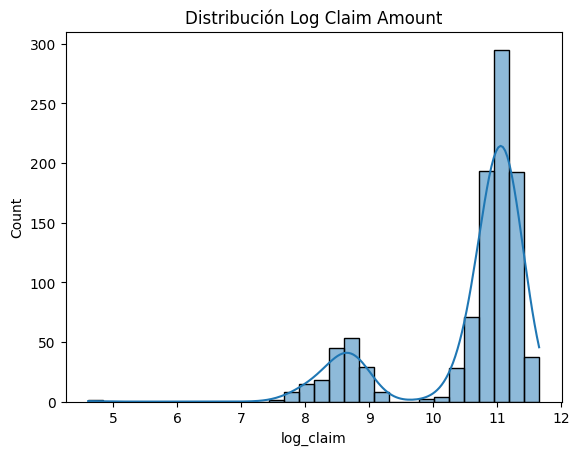

In [35]:
# Se aplica logaritmo al monto del reclamo para reducir la asimetría de los datos
# y hacer que la distribución sea más uniforme, lo que facilita su análisis.

df2["log_claim"] = np.log(df2["total_claim_amount"])

sns.histplot(df2["log_claim"], bins=30, kde=True)
plt.title("Distribución Log Claim Amount")
plt.show()

In [36]:
# Convertir fechas
df2["policy_bind_date"] = pd.to_datetime(df2["policy_bind_date"])
df2["incident_date"] = pd.to_datetime(df2["incident_date"])

# 1. policy_tenure_days:
# Días transcurridos entre la contratación de la póliza y la fecha del incidente.
df2["policy_tenure_days"] = (df2["incident_date"] - df2["policy_bind_date"]).dt.days

# 2. vehicle_age:
# Edad del vehículo al momento del incidente.
df2["vehicle_age"] = df2["incident_date"].dt.year - df2["auto_year"]

# 3. incident_month:
# Mes en el que ocurrió el incidente.
df2["incident_month"] = df2["incident_date"].dt.month

# 4. incident_period:
# Periodo del día en que ocurrió el incidente (madrugada, mañana, tarde o noche).
def time_of_day(hour):
    if hour < 8:
        return "1"
    elif hour < 16:
        return "2"
    else:
        return "3"

df2["incident_period"] = df2["incident_hour_of_the_day"].apply(time_of_day)

# 5. premium_to_deductible:
# Relación entre la prima anual y el deducible de la póliza.
df2["premium_to_deductible"] = df2["policy_annual_premium"] / df2["policy_deductable"]

# 6. injury_vehicle_interaction:
# Variable de interacción entre número de lesionados y número de vehículos involucrados.
df2["injury_vehicle_interaction"] = df2["bodily_injuries"] * df2["number_of_vehicles_involved"]

# Verificación rápida
print(df2[[
    "policy_tenure_days",
    "vehicle_age",
    "incident_month",
    "incident_period",
    "premium_to_deductible",
    "injury_vehicle_interaction"
]].head())

   policy_tenure_days  vehicle_age  incident_month incident_period  \
0                 100           11               1               1   
1                3130            8               1               2   
2                5282            8               2               1   
3                8996            1               1               1   
4                 256            6               2               3   

   premium_to_deductible  injury_vehicle_interaction  
0                1.40691                           1  
1                0.59861                           0  
2                0.70657                           6  
3                0.70787                           1  
4                1.58391                           0  


In [37]:
# Variables originales que ya fueron resumidas en nuevas features
cols_to_drop = [
    "policy_bind_date",
    "incident_date",
    "incident_hour_of_the_day",
    "auto_year"
]

# Eliminarlas del dataframe
df2 = df2.drop(columns=cols_to_drop)

# Verificar resultado
print("Columnas restantes:", df2.shape[1])
print(df2.columns.tolist())

Columnas restantes: 36
['months_as_customer', 'age', 'policy_state', 'policy_csl', 'policy_deductable', 'policy_annual_premium', 'umbrella_limit', 'insured_sex', 'insured_education_level', 'insured_occupation', 'insured_hobbies', 'insured_relationship', 'capital-gains', 'capital-loss', 'incident_type', 'collision_type', 'incident_severity', 'authorities_contacted', 'incident_state', 'incident_city', 'number_of_vehicles_involved', 'property_damage', 'bodily_injuries', 'witnesses', 'police_report_available', 'total_claim_amount', 'auto_make', 'auto_model', 'loss_ratio', 'log_claim', 'policy_tenure_days', 'vehicle_age', 'incident_month', 'incident_period', 'premium_to_deductible', 'injury_vehicle_interaction']


In [38]:
# seleccionar variables numericas
num_vars = df2.select_dtypes(include=["int64","float64"])

# matriz de correlacion
corr_matrix = num_vars.corr()

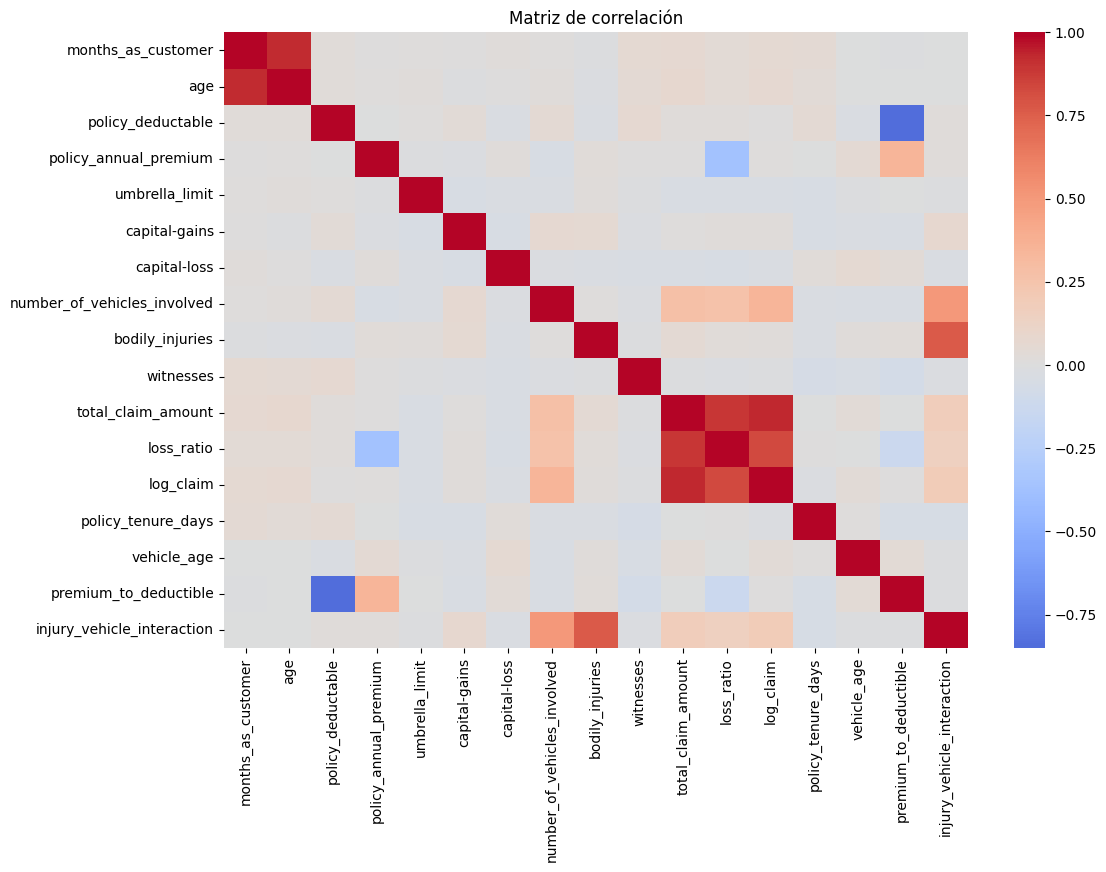

In [39]:
# Se crea un mapa de calor (heatmap) de la matriz de correlación
plt.figure(figsize=(12,8))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0
)

plt.title("Matriz de correlación")
plt.show()

In [40]:
#Correlacion con respecto a la variable target (total claims)

corr_with_target = corr_matrix["total_claim_amount"].sort_values(ascending=True)

print(corr_with_target)

umbrella_limit                -0.040344
capital-loss                  -0.036060
witnesses                     -0.011114
premium_to_deductible         -0.001208
policy_tenure_days            -0.000793
policy_annual_premium          0.009094
capital-gains                  0.015980
policy_deductable              0.022839
vehicle_age                    0.035781
bodily_injuries                0.047093
months_as_customer             0.062108
age                            0.069863
injury_vehicle_interaction     0.180611
number_of_vehicles_involved    0.274278
loss_ratio                     0.895840
log_claim                      0.930665
total_claim_amount             1.000000
Name: total_claim_amount, dtype: float64


In [41]:
#variable con baja correlacion contra la variable target, cortamos las varibles con un umbral u = 0.04

low_corr = corr_with_target[abs(corr_with_target) < 0.04]

print(low_corr)

capital-loss            -0.036060
witnesses               -0.011114
premium_to_deductible   -0.001208
policy_tenure_days      -0.000793
policy_annual_premium    0.009094
capital-gains            0.015980
policy_deductable        0.022839
vehicle_age              0.035781
Name: total_claim_amount, dtype: float64


In [42]:
# nombres de las columnas con baja correlación
cols_to_drop = [c for c in low_corr.index if c in df2.columns]

# eliminarlas
df2 = df2.drop(columns=cols_to_drop)

In [43]:
df2.shape

(1000, 28)

In [44]:
#Detectar multicolinealidad entre variables con un umbral de u = 0.85

high_corr_pairs = np.where(abs(corr_matrix) > 0.85)

for i,j in zip(*high_corr_pairs):
    if i < j:
        print(corr_matrix.index[i], "-", corr_matrix.columns[j], ":", corr_matrix.iloc[i,j])

months_as_customer - age : 0.9220983225789804
policy_deductable - premium_to_deductible : -0.8513024875748524
total_claim_amount - loss_ratio : 0.8958401105728995
total_claim_amount - log_claim : 0.9306645836117768


In [45]:
# Definimos una lista con las columnas que queremos eliminar del DataFrame.
cols_to_drop = ["months_as_customer", "premium_to_deductible", "log_claim"]
existing_drop = [c for c in cols_to_drop if c in df2.columns]

df2 = df2.drop(columns=existing_drop)


print("Nuevo shape:", df2.shape)

Nuevo shape: (1000, 26)


In [46]:
#revisamos granularidad en varibales para ver que tan bien nos pueden servir y si no se haria un exceso al hacer un one-hot encoding

for col in df2.select_dtypes(include="object").columns:
    print(f"\n{col}")
    print(df2[col].value_counts(dropna=False))


policy_state
policy_state
OH    352
IL    338
IN    310
Name: count, dtype: int64

policy_csl
policy_csl
250/500     351
100/300     349
500/1000    300
Name: count, dtype: int64

insured_sex
insured_sex
FEMALE    537
MALE      463
Name: count, dtype: int64

insured_education_level
insured_education_level
JD             161
High School    160
Associate      145
MD             144
Masters        143
PhD            125
College        122
Name: count, dtype: int64

insured_occupation
insured_occupation
machine-op-inspct    93
prof-specialty       85
tech-support         78
sales                76
exec-managerial      76
craft-repair         74
transport-moving     72
priv-house-serv      71
other-service        71
armed-forces         69
adm-clerical         65
protective-serv      63
handlers-cleaners    54
farming-fishing      53
Name: count, dtype: int64

insured_hobbies
insured_hobbies
reading           64
exercise          57
paintball         57
bungie-jumping    56
movies         

In [47]:
#Eliminamos nulos

df2 = df2.dropna()

In [48]:
df2.shape

(909, 26)

In [49]:
#vemos la informacion de los datos nuevos que tenemos
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 909 entries, 0 to 999
Data columns (total 26 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   age                          909 non-null    int64  
 1   policy_state                 909 non-null    object 
 2   policy_csl                   909 non-null    object 
 3   umbrella_limit               909 non-null    int64  
 4   insured_sex                  909 non-null    object 
 5   insured_education_level      909 non-null    object 
 6   insured_occupation           909 non-null    object 
 7   insured_hobbies              909 non-null    object 
 8   insured_relationship         909 non-null    object 
 9   incident_type                909 non-null    object 
 10  collision_type               909 non-null    object 
 11  incident_severity            909 non-null    object 
 12  authorities_contacted        909 non-null    object 
 13  incident_state           

In [50]:
# Seleccionamos las columnas 'incident_period' y 'policy_csl',
# luego agrupamos los datos por 'incident_period' y contamos
# cuántos registros hay en cada periodo.
df2[['incident_period', 'policy_csl']].groupby('incident_period').count()

,policy_csl
incident_period,
1,276
2,293
3,340


In [51]:
# Convertimos 'incident_period' a número entero.
df2['incident_period'] = df2['incident_period'].astype(int)


In [52]:
# variables que queremos usar en el modelo
var_model = [
    "incident_type",
    "collision_type",
    "incident_severity",
    "incident_city",
    "auto_make",
    "number_of_vehicles_involved",
    "age",
    "incident_period",
    "policy_csl"
]

# seleccionar esas variables del dataframe
df_model = df2[var_model].copy()

# identificar variables categóricas
cat_vars = df_model.select_dtypes(include="object").columns

# aplicar one-hot encoding
df_model = pd.get_dummies(df_model, columns=cat_vars, drop_first=True)

# ver resultado
print("Dimensión del dataframe codificado:", df_model.shape)
df_model.head()

Dimensión del dataframe codificado: (909, 33)


,number_of_vehicles_involved,age,incident_period,incident_type_Parked Car,incident_type_Single Vehicle Collision,incident_type_Vehicle Theft,collision_type_Front Collision,collision_type_Rear Collision,collision_type_Side Collision,incident_severity_Minor Damage,...,auto_make_Honda,auto_make_Jeep,auto_make_Mercedes,auto_make_Nissan,auto_make_Saab,auto_make_Suburu,auto_make_Toyota,auto_make_Volkswagen,policy_csl_250/500,policy_csl_500/1000
0,1,48,1,False,True,False,False,False,True,False,...,False,False,False,False,True,False,False,False,True,False
1,1,42,2,False,False,True,False,False,False,True,...,False,False,True,False,False,False,False,False,True,False
2,3,29,1,False,False,False,False,True,False,True,...,False,False,False,False,False,False,False,False,False,False
3,1,41,1,False,True,False,True,False,False,False,...,False,False,False,False,False,False,False,False,True,False
5,3,39,3,False,False,False,False,True,False,False,...,False,False,False,False,True,False,False,False,True,False


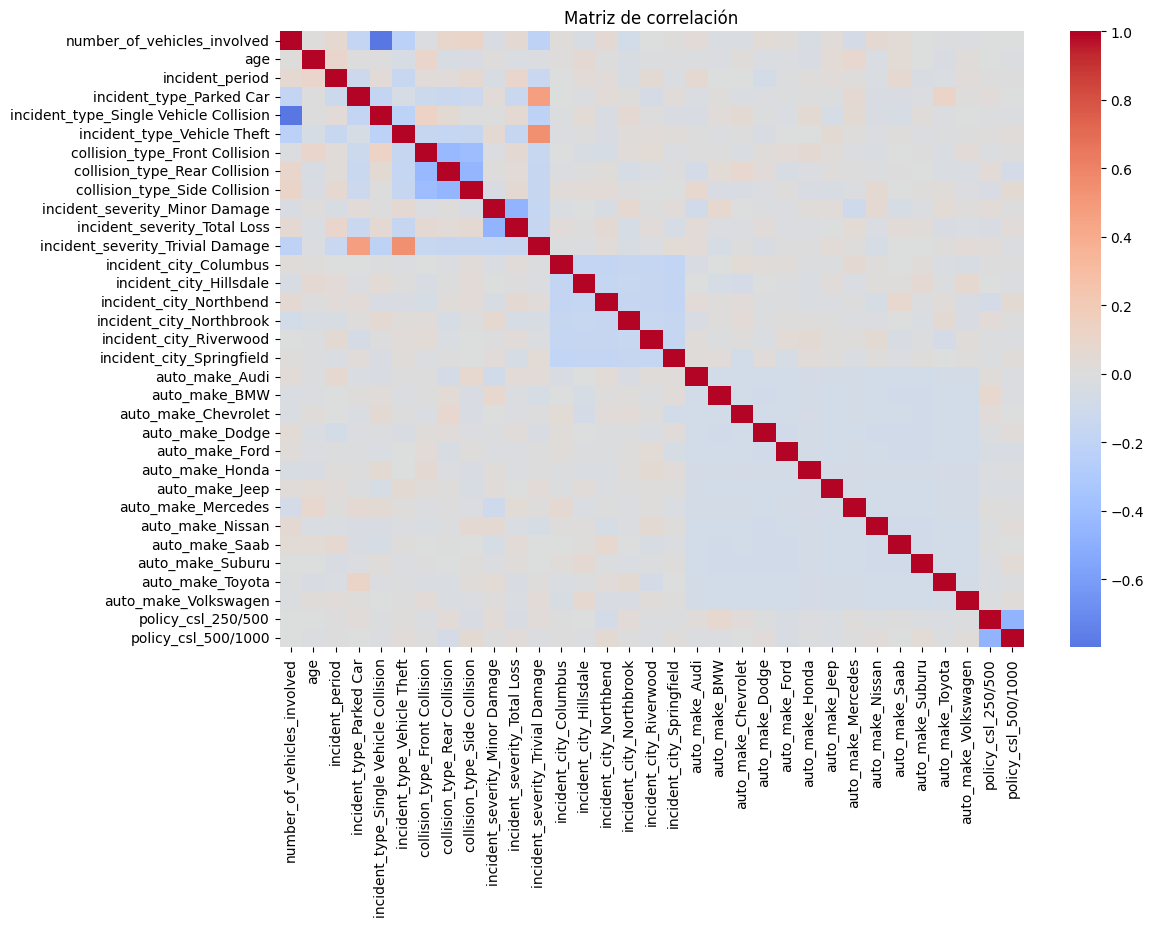

In [53]:
# Calculamos la matriz de correlación y la mostramos con un mapa de calor.
corr_matrix = df_model.corr()

plt.figure(figsize=(12,8))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0
)

plt.title("Matriz de correlación")
plt.show()



In [54]:
# Buscamos pares de variables con correlación mayor a 0.5 y mostramos cuáles son.
high_corr_pairs = np.where(abs(corr_matrix) > 0.5)

for i,j in zip(*high_corr_pairs):
    if i < j:
        print(corr_matrix.index[i], "-", corr_matrix.columns[j], ":", corr_matrix.iloc[i,j])

number_of_vehicles_involved - incident_type_Single Vehicle Collision : -0.7987884251017726
incident_type_Vehicle Theft - incident_severity_Trivial Damage : 0.5434973876031358


In [55]:
# Definimos las variables independientes (X) y la variable objetivo (Y).
X = df2[var_model]
Y = df2["total_claim_amount"]



In [56]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# convertir categóricas a numéricas
X = pd.get_dummies(X, drop_first=True)

# dividir datos
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.3, random_state=42
)

# crear modelo
lrm = LinearRegression()

# entrenar modelo
lrm.fit(X_train, y_train)

LinearRegression()

##**Modelo totalmente bueno**

In [62]:
# Definir variables
x_1 = df_1[[
    "vehicle_claim",
    "property_claim",
    "injury_claim"
    ]]
Y = df_1[['total_claim_amount']]

# Convertir categóricas a numéricas usando one-hot encoding
x_1 = pd.get_dummies(x_1, drop_first=True)

#Separacion entre muestras
X_train, X_test, Y_train, Y_test = train_test_split(x_1,Y, test_size=0.3, random_state=42)

#Entrenar el modelo
lrm = LinearRegression()

lrm.fit(X_train, Y_train)

#Predicciones
from sklearn import metrics
import statsmodels.api as sm

#Regresa un array
predicciones = lrm.predict(X_train)

X_train_sm = sm.add_constant(X_train)
X_train_sm = X_train_sm.astype(float) # Ensure all columns are numeric
X_test_sm = sm.add_constant(X_test)
X_test_sm = X_test_sm.astype(float) # Ensure all columns are numeric

Y_train_sm = Y_train
Y_test_sm = Y_test

model = sm.OLS(Y_train_sm, X_train_sm)

lrm_results = model.fit()

print(lrm_results.summary())

                            OLS Regression Results                            
Dep. Variable:     total_claim_amount   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 1.152e+32
Date:                Sat, 14 Mar 2026   Prob (F-statistic):               0.00
Time:                        05:16:48   Log-Likelihood:                 15818.
No. Observations:                 700   AIC:                        -3.163e+04
Df Residuals:                     696   BIC:                        -3.161e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              -1e-11   3.24e-12     -3.

In [63]:
from sklearn import metrics

In [64]:
# Generamos las predicciones del modelo usando los datos de prueba.
predicciones = lrm.predict(X_test)

In [65]:
# Mostramos las primeras observaciones de Y_test y el número total de datos en el conjunto de prueba.
Y_test.head()
Y_test.head()
len(Y_test)

300

In [66]:
predicciones

array([[ 88110.],
       [ 52800.],
       [ 67600.],
       [ 62800.],
       [  6820.],
       [ 69300.],
       [ 72840.],
       [ 53730.],
       [ 48950.],
       [  3690.],
       [  4680.],
       [ 89400.],
       [  5490.],
       [ 49100.],
       [ 68240.],
       [  4700.],
       [ 46560.],
       [ 34160.],
       [ 68200.],
       [ 74280.],
       [ 67210.],
       [  6100.],
       [ 44110.],
       [  2700.],
       [  6120.],
       [ 76560.],
       [ 52800.],
       [ 77000.],
       [ 60000.],
       [ 43560.],
       [ 39480.],
       [ 73560.],
       [ 34650.],
       [ 73370.],
       [ 52560.],
       [ 59400.],
       [ 95900.],
       [  6030.],
       [ 40500.],
       [ 62920.],
       [ 51810.],
       [ 72930.],
       [ 35000.],
       [ 98280.],
       [ 63720.],
       [ 60390.],
       [ 32670.],
       [ 64080.],
       [  5900.],
       [  5940.],
       [ 36400.],
       [ 58560.],
       [ 59000.],
       [ 51090.],
       [ 98160.],
       [ 7

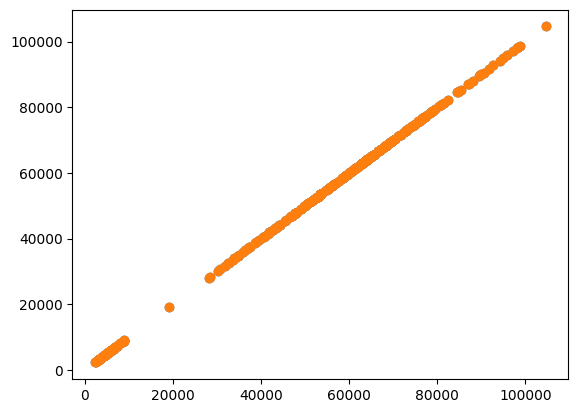

In [67]:
# Graficamos los valores reales contra las predicciones para comparar el ajuste del modelo.
plt.scatter(Y_test, predicciones)
plt.scatter(Y_test, predicciones)

auto_model
sex
hobbies
education

In [68]:
# Definir variables
x_2 = df[[
    "vehicle_claim",
    "incident_type",
    "collision_type"

    ]]
Y = df[['total_claim_amount']]

# Convertir categóricas a numéricas usando one-hot encoding
x_2 = pd.get_dummies(x_2, drop_first=True)

#Separacion entre muestras
X_train, X_test, Y_train, Y_test = train_test_split(x_2,Y, test_size=0.3, random_state=42)

#Entrenar el modelo
lrm = LinearRegression()

lrm.fit(X_train, Y_train)

#Predicciones
from sklearn import metrics
import statsmodels.api as sm

#Regresa un array
predicciones = lrm.predict(X_train)

X_train_sm = sm.add_constant(X_train)
X_train_sm = X_train_sm.astype(float) # Ensure all columns are numeric
X_test_sm = sm.add_constant(X_test)
X_test_sm = X_test_sm.astype(float) # Ensure all columns are numeric

Y_train_sm = Y_train
Y_test_sm = Y_test

model = sm.OLS(Y_train_sm, X_train_sm)

lrm_results = model.fit()

print(lrm_results.summary())

                            OLS Regression Results                            
Dep. Variable:     total_claim_amount   R-squared:                       0.965
Model:                            OLS   Adj. R-squared:                  0.965
Method:                 Least Squares   F-statistic:                     3212.
Date:                Sat, 14 Mar 2026   Prob (F-statistic):               0.00
Time:                        05:17:02   Log-Likelihood:                -6937.6
No. Observations:                 700   AIC:                         1.389e+04
Df Residuals:                     693   BIC:                         1.392e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                                             coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------

In [69]:
# Generamos las predicciones del modelo y revisamos cuántas se obtuvieron.
predicciones = lrm.predict(X_test)
len(predicciones)

300

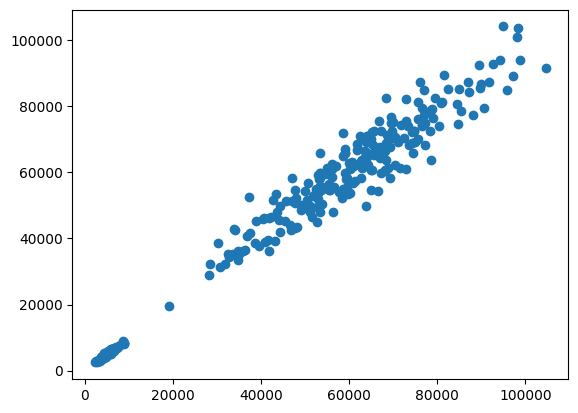

In [70]:
# Graficamos valores reales vs predicciones para ver el ajuste del modelo.
plt.scatter(Y_test, predicciones)

In [71]:
# Calculamos el error como la diferencia entre los valores reales y las predicciones.
error = Y_test - predicciones

Media del error (mu): -299.867763315888
Desviación estándar (sigma): 4782.436282532302


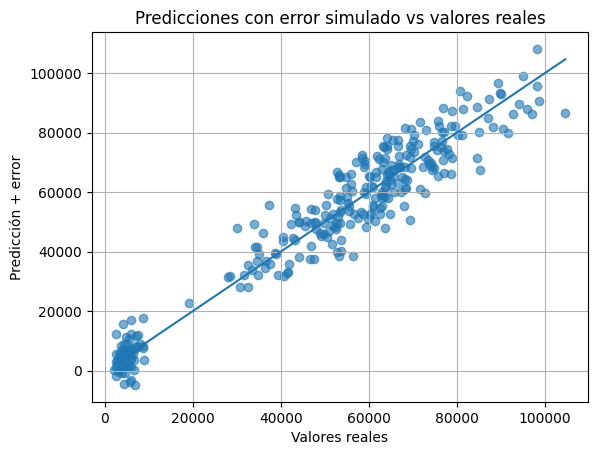

In [72]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from scipy.stats import norm


# ajustar normal a los errores
mu, sigma = norm.fit(error)

print("Media del error (mu):", mu)
print("Desviación estándar (sigma):", sigma)

# generar errores simulados con la normal ajustada
error_sim = np.random.normal(mu, sigma, len(predicciones))

# nuevas predicciones con error
y_pred_error = predicciones.flatten() + error_sim

# gráfica
plt.scatter(Y_test.values.flatten(), y_pred_error.flatten(), alpha=0.6)

# línea perfecta
min_val = Y_test.min().values[0]
max_val = Y_test.max().values[0]
plt.plot([min_val, max_val],
         [min_val, max_val])

plt.xlabel("Valores reales")
plt.ylabel("Predicción + error")
plt.title("Predicciones con error simulado vs valores reales")
plt.grid(True)

plt.show()

In [73]:
# Calculamos métricas de desempeño del modelo (R2, MSE, RMSE y MAE)
# para evaluar qué tan bien se ajustan las predicciones a los valores reales.

r2 = r2_score(Y_test.values.flatten(), y_pred_error.flatten())
mse = mean_squared_error(Y_test.values.flatten(), y_pred_error.flatten())
rmse = np.sqrt(mse)
mae = mean_absolute_error(Y_test.values.flatten(), y_pred_error.flatten())

print("Metricas considerando el ajuste de error con una normal")
print("R2 :", r2)
print("MSE:", mse)
print("RMSE:", rmse)
print("MAE:", mae)

Metricas considerando el ajuste de error con una normal
R2 : 0.9316862977894916
MSE: 48693770.30267874
RMSE: 6978.092167826299
MAE: 5562.882771483047
